# Notebook 04 - Modelling and Evaluation

**Author:** Talia Low | **Date:** March 2026

This notebook trains and compares candidate classifiers using the preprocessed
`train`, `val`, and `holdout` feature matrices produced by Notebook 03.

The upstream workflow is:
- Notebook 02 created the **development / holdout** split and the **train / validation** split
- Notebook 03 applied feature engineering and preprocessing using `df_train` only

This notebook focuses on:
1. training models on `X_train, y_train`,
2. comparing them on `X_val, y_val`,
3. selecting the best model using **validation metrics**,
4. reporting final performance on the **out-of-time holdout** (`X_holdout, y_holdout`).

**Candidate models:**

| Model | Type | Rationale |
|---|---|---|
| Logistic Regression | Linear baseline | Interpretable benchmark |
| Random Forest | Bagging ensemble | Captures non-linearity; robust to noise |
| XGBoost | Boosting ensemble | Strong regularised tabular learner |
| LightGBM | Boosting ensemble | Fast histogram-based boosting |

**Validation strategy:** Model comparison and model selection are based on the pre-defined validation set. The out-of-time holdout (Jul–Dec 2017) is reserved for final unseen evaluation only.

## 1. Setup

In [1]:
import gc
import pickle
import warnings
from pathlib import Path

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    accuracy_score
)

import optuna
import shap
import lime,lime.lime_tabular

# warnings.filterwarnings("ignore", category=UserWarning)
plt.style.use("seaborn-v0_8-whitegrid")

# Global random seed for reproducibility
SEED = 42

# Define project folders used in this notebook
PROCESSED_DIR = Path("../data/processed")
FIGURES_DIR = Path("../reports/figures")
MODEL_DIR = Path("../models")
# Create output folders if they do not already exist
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

COLORS = {
    "default": "#d62728",
    "non_default": "#1f77b4",
    "lr": "#2ca02c",
    "rf": "#ff7f0e",
    "xgb": "#8c564b",
    "lgbm": "#e377c2",
}

color_map = {
    "Logistic Regression": COLORS["lr"],
    "Random Forest": COLORS["rf"],
    "XGBoost": COLORS["xgb"],
    "LightGBM": COLORS["lgbm"],
    "XGBoost (Baseline)": "#f5c6a0",
    "XGBoost (Tuned)": COLORS["xgb"],
    "LightGBM (Baseline)": "#a8d8a8",
    "LightGBM (Tuned)": COLORS["lgbm"],
}

## 2. Load Preprocessed Data

In [2]:
# Load preprocessed arrays from Notebook 03
# Feature matrices
X_train = np.load(PROCESSED_DIR / "X_train.npy")
X_val = np.load(PROCESSED_DIR / "X_val.npy")
X_holdout = np.load(PROCESSED_DIR / "X_holdout.npy")

# Target arrays
y_train = np.load(PROCESSED_DIR / "y_train.npy")
y_val = np.load(PROCESSED_DIR / "y_val.npy")
y_holdout = np.load(PROCESSED_DIR / "y_holdout.npy")

# Load the processed feature names so we can later interpret feature importance
with open(PROCESSED_DIR / "feature_names.pkl", "rb") as f:
    feature_names = pickle.load(f)

# Quick sanity check on data shape and class balance
print(f"Train set:   {X_train.shape[0]:,} samples x {X_train.shape[1]} features ({y_train.mean():.2%} default)")
print(f"Val set:     {X_val.shape[0]:,} samples x {X_val.shape[1]} features ({y_val.mean():.2%} default)")
print(f"Holdout set: {X_holdout.shape[0]:,} samples x {X_holdout.shape[1]} features ({y_holdout.mean():.2%} default)")

Train set:   960,780 samples x 118 features (19.93% default)
Val set:     240,195 samples x 118 features (19.93% default)
Holdout set: 69,339 samples x 118 features (22.20% default)


## 3. Helper Functions

In [3]:
def ks_statistic(y_true, y_prob):
    """Kolmogorov-Smirnov statistic for binary classification scores"""

    # Convert inputs to NumPy arrays for safe vectorised operations
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    # Separate predicted probabilities by actual class
    # y_true == 1 -> default class
    # y_true == 0 -> non-default class
    pos_scores = np.sort(y_prob[y_true == 1])
    neg_scores = np.sort(y_prob[y_true == 0])

    # Evaluate the cumulative distributions at every unique score
    all_scores = np.sort(np.unique(y_prob))
    cdf_pos = np.searchsorted(pos_scores, all_scores, side="right") / len(pos_scores)
    cdf_neg = np.searchsorted(neg_scores, all_scores, side="right") / len(neg_scores)

    # KS is the maximum vertical distance between the two CDFs
    ks = np.max(np.abs(cdf_pos - cdf_neg))
    return float(ks)


def gini_from_auc(auc):
    """Convert ROC-AUC to Gini coefficient"""
    return 2 * auc - 1


def evaluate_model(name, model, X_tr, y_tr, X_v, y_v):
    """Train a model on the training split and evaluate it on the validation split"""

    # Fit the model only on the training data
    model.fit(X_tr, y_tr)

    # Predict probability of the positive class (default = 1) on validation data
    y_prob = model.predict_proba(X_v)[:, 1]

    # Compute ranking and calibration-style metrics
    roc = roc_auc_score(y_v, y_prob)           # Ranking quality across all thresholds
    pr = average_precision_score(y_v, y_prob)  # More informative when classes are imbalanced
    ks = ks_statistic(y_v, y_prob)             # Separation between default and non-default score distributions
    gini = gini_from_auc(roc)                  # Common credit-risk transformation of AUC
    brier = brier_score_loss(y_v, y_prob)      # Probability error, lower is better

    # Print a compact summary for quick comparison across candidate models
    print(
        f"{name:22s} | "
        f"Val ROC-AUC: {roc:.4f} | "
        f"Val PR-AUC: {pr:.4f} | "
        f"Val KS: {ks:.4f} | "
        f"Val Gini: {gini:.4f} | "
        f"Val Brier: {brier:.4f}"
    )

    # Return both the fitted model and validation outputs for later comparison
    return {
        "model": model,
        "y_prob_val": y_prob,
        "Val ROC-AUC": roc,
        "Val PR-AUC": pr,
        "Val KS": ks,
        "Val Gini": gini,
        "Val Brier": brier,
    }

def evaluate_probs(y_true, y_prob):
    roc = roc_auc_score(y_true, y_prob)
    pr = average_precision_score(y_true, y_prob)
    ks = ks_statistic(y_true, y_prob)
    gini = gini_from_auc(roc)
    brier = brier_score_loss(y_true, y_prob)

    return {
        "ROC-AUC": roc,
        "PR-AUC": pr,
        "KS": ks,
        "Gini": gini,
        "Brier": brier,
    }

## 4. Validation-Stage Model Training and Comparison

### 4.1 Logistic Regression

Logistic regression serves as the **interpretable linear baseline**. It establishes the floor of what a linear model can achieve and provides directly interpretable coefficients for comparison.

Because Logistic Regression is more sensitive to multicollinearity than tree-based models, we apply an **additional multi-step pruning pipeline** before fitting the LR benchmark.

This pruning is performed only for Logistic Regression and consists of the following stages:

1. **Near-constant feature removal**  
   Features with almost no variation are removed, as they carry little predictive signal and can cause numerical instability.

2. **Pairwise correlation screening**  
   Highly correlated feature pairs (|r| > 0.9) are identified, and redundant features are removed to eliminate obvious duplication of information.

3. **VIF-based iterative pruning**  
   VIF (Variance Inflation Factor) is used to detect remaining multicollinearity across multiple features simultaneously.  
   - VIF measures how strongly a feature can be explained by the other predictors  
   - A high VIF indicates that the feature is highly redundant, which can inflate coefficient variance and destabilise the model  
   - Features are iteratively removed until all remaining features have **VIF ≤ 10**

Tree-based models continue to use the full processed feature matrix, as they are generally more robust to correlated features and do not require this additional pruning.

In [4]:
# Logistic Regression-only multicollinearity pruning
# Build DataFrames so we can still refer to columns by name
X_train_df = pd.DataFrame(X_train, columns=feature_names)
X_val_df = pd.DataFrame(X_val, columns=feature_names)
X_holdout_df = pd.DataFrame(X_holdout, columns=feature_names)

# Step 1: choose candidate columns for correlation / VIF checks
# Focus on transformed numeric / ordinal-style columns
# One-hot columns are usually left alone here
lr_candidate_cols = [
    c for c in feature_names
    if c.startswith("num__") or c.startswith("ord__")
]

print(f"Initial LR candidate columns: {len(lr_candidate_cols)}")

# Extract candidate matrix as NumPy
X_lr = X_train_df[lr_candidate_cols].to_numpy(dtype=np.float64)

Initial LR candidate columns: 96


In [5]:
# Step 2: remove near-constant columns
stds = X_lr.std(axis=0, ddof=1)
keep_mask = stds > 1e-8

X_lr = X_lr[:, keep_mask]
lr_candidate_cols = [c for c, keep in zip(lr_candidate_cols, keep_mask) if keep]

print(f"After removing near-constant columns: {len(lr_candidate_cols)}")

After removing near-constant columns: 96


In [6]:
# Step 3: pairwise correlation screen
corr_threshold = 0.90

# Correlation matrix using NumPy
corr_matrix = np.corrcoef(X_lr, rowvar=False)
corr_abs = np.abs(corr_matrix)

# Upper triangle only
upper_mask = np.triu(np.ones_like(corr_abs, dtype=bool), k=1)

# Drop a column if it has any correlation above threshold with an earlier column
corr_drop_idx = []
for j in range(corr_abs.shape[1]):
    if np.any(corr_abs[:j, j] > corr_threshold):
        corr_drop_idx.append(j)

corr_drop_cols = [lr_candidate_cols[j] for j in corr_drop_idx]

print(f"Columns dropped by pairwise correlation > {corr_threshold}: {len(corr_drop_cols)}")
if len(corr_drop_cols) > 0:
    print(corr_drop_cols[:20])

# Keep only non-dropped columns
keep_idx = [j for j in range(len(lr_candidate_cols)) if j not in corr_drop_idx]
X_lr = X_lr[:, keep_idx]
lr_vif_cols = [lr_candidate_cols[j] for j in keep_idx]

print(f"Columns entering VIF step: {len(lr_vif_cols)}")

Columns dropped by pairwise correlation > 0.9: 27
['num__installment', 'num__installment_to_income', 'num__revol_bal_to_limit', 'num__delinq_ratio', 'num__log_loan_amnt', 'num__subgrade_num', 'num__tot_cur_bal_missing', 'num__mths_since_rcnt_il_missing', 'num__il_util_missing', 'num__max_bal_bc_missing', 'num__all_util_missing', 'num__total_rev_hi_lim_missing', 'num__inq_fi_missing', 'num__total_cu_tl_missing', 'num__inq_last_12m_missing', 'num__mo_sin_old_rev_tl_op_missing', 'num__mo_sin_rcnt_rev_tl_op_missing', 'num__mo_sin_rcnt_tl_missing', 'num__num_accts_ever_120_pd_missing', 'num__num_actv_rev_tl_missing']
Columns entering VIF step: 69


In [7]:
%%time
# Step 4: iterative VIF pruning 
vif_threshold = 10.0

def compute_vif_numpy(X, col_names):
    """
    Compute VIF from the inverse correlation matrix:
        VIF = diag(inv(corr_matrix))
    Uses pseudo-inverse for numerical stability.
    """
    corr = np.corrcoef(X, rowvar=False)
    inv_corr = np.linalg.pinv(corr)   # more stable than inv for near-collinear matrices
    vif_vals = np.diag(inv_corr)

    vif_df = pd.DataFrame({
        "feature": col_names,
        "VIF": vif_vals
    }).sort_values("VIF", ascending=False).reset_index(drop=True)

    return vif_df

while X_lr.shape[1] > 1:
    vif_df = compute_vif_numpy(X_lr, lr_vif_cols)

    max_vif = vif_df.loc[0, "VIF"]
    max_feat = vif_df.loc[0, "feature"]

    if max_vif <= vif_threshold:
        break

    # Remove the feature with the highest VIF
    drop_idx = lr_vif_cols.index(max_feat)
    X_lr = np.delete(X_lr, drop_idx, axis=1)
    lr_vif_cols.pop(drop_idx)

print(f"Columns remaining after VIF pruning: {len(lr_vif_cols)}")

final_vif_df = compute_vif_numpy(X_lr, lr_vif_cols)
final_vif_df

Columns remaining after VIF pruning: 67
CPU times: user 2.23 s, sys: 7.56 s, total: 9.79 s
Wall time: 1.54 s


,feature,VIF
0,num__subgrade_dti_interaction,9.304734
1,num__log_annual_inc,8.598057
2,num__tot_cur_bal,7.911797
3,num__revol_bal,7.817218
4,num__loan_amnt,7.786732
...,...,...
62,num__delinq_amnt,1.083464
63,num__chargeoff_within_12_mths,1.076594
64,num__collections_12_mths_ex_med,1.030732
65,num__zip3_encoded,1.014869


In [8]:
# Step 5: define final LR feature set
non_candidate_cols = [c for c in feature_names if c not in [
    c for c in feature_names if c.startswith("num__") or c.startswith("ord__")
]]

lr_final_features = non_candidate_cols + lr_vif_cols

print(f"\nFinal LR feature count: {len(lr_final_features)}")
print(f"Original feature count: {len(feature_names)}")
print(f"Features removed for LR only: {len(feature_names) - len(lr_final_features)}")

# Step 6: build LR-specific matrices
X_train_lr = X_train_df[lr_final_features].to_numpy(dtype=np.float32)
X_val_lr = X_val_df[lr_final_features].to_numpy(dtype=np.float32)
X_holdout_lr = X_holdout_df[lr_final_features].to_numpy(dtype=np.float32)

print("\nLR-specific matrices created:")
print(f"  X_train_lr:   {X_train_lr.shape}")
print(f"  X_val_lr:     {X_val_lr.shape}")
print(f"  X_holdout_lr: {X_holdout_lr.shape}")


Final LR feature count: 89
Original feature count: 118
Features removed for LR only: 29

LR-specific matrices created:
  X_train_lr:   (960780, 89)
  X_val_lr:     (240195, 89)
  X_holdout_lr: (69339, 89)


In [9]:
%%time
lr = LogisticRegression(
    C=1.0,                 # Default L2 regularisation strength
    solver="lbfgs",        # Stable default solver for dense, L2-regularised problems
    max_iter=500,         # Increased from default to avoid convergence warnings
    random_state=SEED,     # Reproducibility
    class_weight="balanced"
)

results_lr = evaluate_model("Logistic Regression", lr, X_train_lr, y_train, X_val_lr, y_val)
# Ask Python to free memory from objects that are no longer needed
gc.collect()

Logistic Regression    | Val ROC-AUC: 0.7275 | Val PR-AUC: 0.3982 | Val KS: 0.3319 | Val Gini: 0.4550 | Val Brier: 0.2115
CPU times: user 3min 49s, sys: 1min 22s, total: 5min 12s
Wall time: 29.6 s


22

### 4.2 Random Forest

Random Forest is included as a **bagging-based non-linear benchmark**.
The settings are intentionally conservative:
- `n_estimators=200` provides a more stable ensemble than the default 100 trees
- `max_depth=8` limits tree complexity to reduce overfitting
- `min_samples_leaf=50` prevents overly specific terminal nodes
- `max_features="sqrt"` is the standard RF setting to decorrelate trees
- `class_weight="balanced_subsample"` makes each bootstrap sample more sensitive to the minority default class


Note: For Random Forest its trees are allowed to be somewhat deeper than the boosting models because bagging averages across many independently trained trees, which usually makes it less sensitive to overfitting than boosting.

For this reason, tree complexity is **regularised separately by algorithm**, rather than forcing the same depth across Random Forest, XGBoost, and LightGBM.

In [10]:
%%time
# Random Forest is the bagging-based non-linear benchmark
# These settings are intentionally conservative to reduce overfitting
rf = RandomForestClassifier(
    n_estimators=200,              # More trees for a stabler ensemble
    max_depth=8,                   # Regularise tree depth
    min_samples_leaf=50,           # Avoid very small noisy leaves
    max_features="sqrt",           # Standard RF feature sampling
    class_weight="balanced_subsample",  # Imbalance-aware weighting in each bootstrap sample
    random_state=SEED,             # Reproducibility
    n_jobs=-1,                     # Use all CPU cores
)

results_rf = evaluate_model("Random Forest", rf, X_train, y_train, X_val, y_val)
gc.collect()

Random Forest          | Val ROC-AUC: 0.7201 | Val PR-AUC: 0.3891 | Val KS: 0.3165 | Val Gini: 0.4402 | Val Brier: 0.2148
CPU times: user 7min 57s, sys: 8.62 s, total: 8min 6s
Wall time: 50.3 s


46

### 4.3 XGBoost

XGBoost is configured as a **regularised boosting benchmark**:
- shallow trees (`max_depth=4`) to improve generalisation
    - For boosting models, shallow trees often generalise better because each tree is only meant to add a small correction to the existing ensemble rather than fit the full structure of the data on its own
- smaller learning rate (`0.05`) with more rounds (`400`)
- row and column subsampling for regularisation
- mild L1/L2 regularisation
- `scale_pos_weight` derived from the training-set class ratio to address class imbalance

In [11]:
# Compute class imbalance ratio for XGBoost
# This tells XGBoost how much more heavily to weight the positive class
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos = neg_count / pos_count

# XGBoost is a boosting benchmark with regularisation and shallow trees
xgb_model = xgb.XGBClassifier(
    n_estimators=400,         # Enough rounds for a lower learning rate
    max_depth=4,              # Shallow trees for better generalisation
    learning_rate=0.05,       # Conservative step size
    subsample=0.8,            # Row subsampling regularises the model
    colsample_bytree=0.8,     # Feature subsampling regularises the model
    min_child_weight=5,       # Avoid unstable splits on tiny effective sample sizes
    reg_alpha=0.1,            # Mild L1 regularisation
    reg_lambda=1.0,           # Standard L2 regularisation
    scale_pos_weight=scale_pos,  # Adjust for minority default class
    eval_metric="auc",        # Ranking-oriented metric
    random_state=SEED,        # Reproducibility
    n_jobs=-1,                # Use all CPU cores
    verbosity=0,              # Suppress verbose training log outputs
)

results_xgb = evaluate_model("XGBoost", xgb_model, X_train, y_train, X_val, y_val)
gc.collect()

XGBoost                | Val ROC-AUC: 0.7357 | Val PR-AUC: 0.4120 | Val KS: 0.3440 | Val Gini: 0.4714 | Val Brier: 0.2090


46

### 4.4 LightGBM

LightGBM is configured as another **strong tabular boosting benchmark**:
- low learning rate with more rounds
- minimum leaf size to prevent overfitting
- row and feature subsampling for regularisation
- `is_unbalance=True` to let LightGBM internally reweight the minority class
- Unlike Random Forest, LightGBM is also a boosting model, so tree complexity is kept deliberately conservative.  
To make the comparison with XGBoost cleaner, LightGBM is given an explicit shallow `max_depth`, and `num_leaves` is kept consistent with that depth.

In [12]:
# LightGBM is another boosting-based benchmark designed for efficient tabular learning
# Tree complexity is kept conservative because boosting models can overfit more easily than bagging models such as Random Forest
lgbm = lgb.LGBMClassifier(
    n_estimators=400,         # Enough rounds for a low learning rate
    learning_rate=0.05,       # Conservative step size

    # Keep LightGBM in a similar complexity range to shallow XGBoost
    max_depth=4,              # Explicit depth cap for better generalisation
    num_leaves=15,            # Keep leaf count aligned with depth=4

    min_child_samples=50,     # Regularise leaf growth
    subsample=0.8,            # Row subsampling
    colsample_bytree=0.8,     # Feature subsampling
    reg_alpha=0.1,            # Mild L1 regularisation
    reg_lambda=1.0,           # Standard L2 regularisation
    is_unbalance=True,        # Built-in imbalance handling
    random_state=SEED,        # Reproducibility
    n_jobs=-1,                # Use all CPU cores
    verbose=-1,               # Suppress verbose output
)

results_lgbm = evaluate_model("LightGBM", lgbm, X_train, y_train, X_val, y_val)
gc.collect()

/opt/anaconda3/envs/nlp_basics/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM               | Val ROC-AUC: 0.7355 | Val PR-AUC: 0.4122 | Val KS: 0.3427 | Val Gini: 0.4710 | Val Brier: 0.2094


35

### 4.5 Validation Set Comparison

The table and chart below compare the candidate models on the validation set.

- Model comparison is based primarily on **validation ROC-AUC**, because the core objective is to rank higher-risk borrowers ahead of lower-risk borrowers in a threshold-independent way
- **KS** is used as the main credit-risk-specific supporting metric because it measures separation between defaulters and non-defaulters, while **PR-AUC** provides an additional view of minority-class performance. **Brier score** is also reported as a diagnostic check on probability quality.

Tree depth is **not forced to be identical across algorithms**, because Random Forest, XGBoost, and LightGBM use trees differently. Instead, complexity is controlled separately so that each model remains reasonably regularised and comparable.

Based on this validation comparison, the top-ranked model is selected for downstream holdout evaluation. The operating threshold is chosen separately after model selection, since threshold choice should reflect business objectives such as expected loss, rejection rate, or manual-review capacity.

In [13]:
# Combine validation metrics from all candidate models into one table
all_results = {
    "Logistic Regression": results_lr,
    "Random Forest": results_rf,
    "XGBoost": results_xgb,
    "LightGBM": results_lgbm,
}

# Build a validation summary table
# For each model:
# - take the validation metrics from its results dictionary
# - store them as one row in a DataFrame
#
# Metrics included:
# - Val ROC-AUC : main threshold-independent ranking metric
# - Val PR-AUC  : useful when the positive class is the minority class
# - Val KS      : separation between default and non-default score distributions
# - Val Gini    : common credit-risk transformation of ROC-AUC
# - Val Brier   : probability error; lower is better
val_summary = pd.DataFrame({
    name: {
        "Val ROC-AUC": r["Val ROC-AUC"],
        "Val PR-AUC": r["Val PR-AUC"],
        "Val KS": r["Val KS"],
        "Val Gini": r["Val Gini"],
        "Val Brier": r["Val Brier"],
    }
    for name, r in all_results.items()
}).T

# Rank the models
# Sorting logic:
# 1. highest validation ROC-AUC first
# 2. if ROC-AUC is close, prefer higher KS
# 3. if still close, prefer higher PR-AUC
#
# ROC-AUC is the main model-selection metric, while KS and PR-AUC are supporting metrics
val_summary = val_summary.sort_values(
    ["Val ROC-AUC", "Val KS", "Val PR-AUC"],
    ascending=[False, False, False],
)


val_summary

,Val ROC-AUC,Val PR-AUC,Val KS,Val Gini,Val Brier
XGBoost,0.735719,0.412013,0.343992,0.471438,0.209008
LightGBM,0.735481,0.412151,0.342731,0.470962,0.209375
Logistic Regression,0.727496,0.398193,0.331860,0.454993,0.211504
Random Forest,0.720085,0.389129,0.316499,0.440170,0.214808


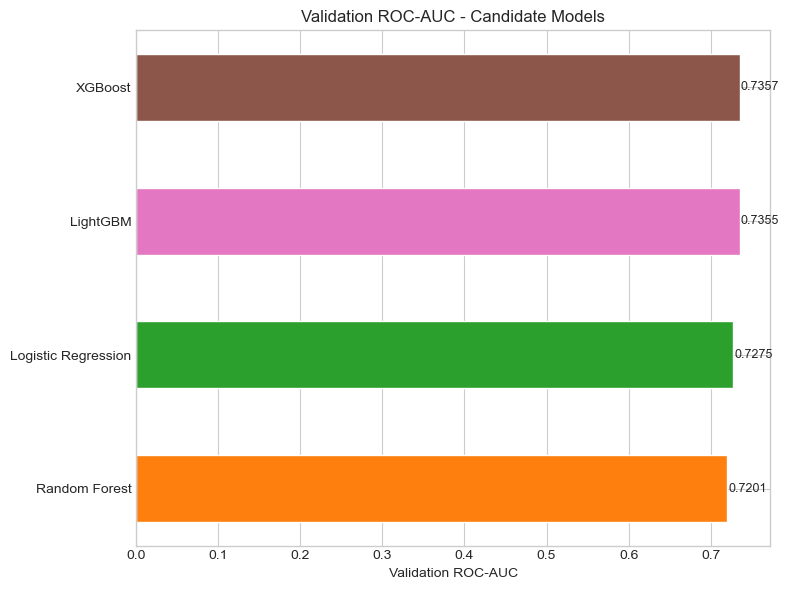

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))
model_order = val_summary.index.tolist()
bar_colors = [color_map[m] for m in model_order]

ax.barh(
    model_order[::-1],
    val_summary["Val ROC-AUC"].values[::-1],
    color=bar_colors[::-1],
    edgecolor="white",
    height = 0.5
)
ax.set_xlabel("Validation ROC-AUC")
ax.set_title("Validation ROC-AUC - Candidate Models")

for i, val in enumerate(val_summary["Val ROC-AUC"].values[::-1]):
    ax.text(val + 0.001, i, f"{val:.4f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "val_comparison_all_models.png", dpi=150, bbox_inches="tight")
plt.show()

> **Validation observations (benchmark models):**
>
> All models outperform random prediction, confirming that the origination-time features carry meaningful default-risk signal. The 2 boosting models - XGBoost and LightGBM - perform similarly at this stage, both outperforming Logistic Regression and Random Forest. Because the gap between them is small, **both boosting models are selected for Optuna hyperparameter tuning** in Section 4.6. The tuned results will be compared in Section 4.7 before proceeding to holdout evaluation.

### 4.6 Hyperparameter Tuning with Optuna

Because XGBoost and LightGBM achieve similar validation performance at their benchmark settings, both are tuned with Optuna to determine whether either model has a meaningful advantage once hyperparameters are optimised.

**Tuning strategy:**
- Optimisation target: **validation ROC-AUC** (primary credit-risk ranking metric)
- Supporting metrics tracked per trial: KS, PR-AUC, Gini, Brier score
- Search budget: **30 trials per model** (sufficient to explore the key hyperparameter interactions without excessive runtime)
- The validation set is used exclusively for tuning; the holdout set remains unseen until Section 5

Both studies are run independently. The best parameters from each study are used to retrain a final tuned model on the full training set.

#### 4.6.1 XGBoost Optuna Tuning

In [15]:
# Keep a copy of the baseline XGBoost result so that we can compare the baseline and tuned versions later
results_xgb_baseline = results_xgb.copy()

def xgb_objective(trial):
    """
    Optuna objective function for XGBoost:
    Each trial proposes a different set of hyperparameters
    The model is trained on the training split and evaluated on the validation split
    Validation ROC-AUC is the metric to maximise
    """

    params = {
        # Number of boosting rounds
        "n_estimators": trial.suggest_int("n_estimators", 300, 900, step=100),

        # Keep trees shallow to reduce overfitting risk
        "max_depth": trial.suggest_int("max_depth", 3, 5),

        # Conservative learning rate
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.08, log=True),

        # Row and feature subsampling regularise the model
        "subsample": trial.suggest_float("subsample", 0.7, 0.9),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 0.9),

        # Require stronger support before creating child nodes
        "min_child_weight": trial.suggest_int("min_child_weight", 3, 15),

        # Explicit regularisation
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),

        # Handle class imbalance using the training-set class ratio
        "scale_pos_weight": scale_pos,

        # Faster CPU tree construction
        "tree_method": "hist",

        # Monitor AUC during training
        "eval_metric": "auc",

        # Reproducibility and speed
        "random_state": SEED,
        "n_jobs": -1,
        "verbosity": 0,
    }

    model = xgb.XGBClassifier(**params)

    # Keep the training procedure consistent with the baseline comparison.
    # If your installed XGBoost version supports early_stopping_rounds cleanly,
    # you can add it here, but this simpler version is stable.
    model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        verbose=False,
    )

    y_prob = model.predict_proba(X_val)[:, 1]
    metrics = evaluate_probs(y_val, y_prob)

    # Store supporting metrics for later inspection
    trial.set_user_attr("Val ROC-AUC", metrics["ROC-AUC"])
    trial.set_user_attr("Val PR-AUC", metrics["PR-AUC"])
    trial.set_user_attr("Val KS", metrics["KS"])
    trial.set_user_attr("Val Gini", metrics["Gini"])
    trial.set_user_attr("Val Brier", metrics["Brier"])

    return metrics["ROC-AUC"]

In [16]:
%%time
optuna.logging.set_verbosity(optuna.logging.WARNING)

xgb_study = optuna.create_study(
    direction="maximize",
    study_name="xgb_auc_optimization"
)

xgb_study.optimize(xgb_objective, n_trials=30, show_progress_bar=True)

print("Best XGBoost trial:")
print("  ROC-AUC:", round(xgb_study.best_value, 4))
print("  Params:", xgb_study.best_params)

  0%|          | 0/30 [00:00<?, ?it/s]

Best XGBoost trial:
  ROC-AUC: 0.7393
  Params: {'n_estimators': 800, 'max_depth': 5, 'learning_rate': 0.05910508262932605, 'subsample': 0.8479097786365349, 'colsample_bytree': 0.7434454038292551, 'min_child_weight': 7, 'reg_alpha': 0.004102417274823918, 'reg_lambda': 0.001786746164793891}
CPU times: user 2h 20min 7s, sys: 43min 25s, total: 3h 3min 32s
Wall time: 16min 57s


In [17]:
# Refit XGBoost using the best hyperparameters from Optuna
best_xgb_params = {
    **xgb_study.best_params,
    "scale_pos_weight": scale_pos,
    "eval_metric": "auc",
    "tree_method": "hist",
    "random_state": SEED,
    "n_jobs": -1,
    "verbosity": 0,
}

# Build the tuned XGBoost model
xgb_tuned = xgb.XGBClassifier(**best_xgb_params)

# Refit on the same train / validation setup used for comparison
results_xgb_tuned = evaluate_model(
    "XGBoost (Tuned)",
    xgb_tuned,
    X_train,
    y_train,
    X_val,
    y_val,
)

gc.collect()

print(f"\nXGBoost Baseline  — Val ROC-AUC: {results_xgb_baseline['Val ROC-AUC']:.4f}")
print(f"XGBoost Tuned     — Val ROC-AUC: {results_xgb_tuned['Val ROC-AUC']:.4f}")
print(f"Improvement       : {results_xgb_tuned['Val ROC-AUC'] - results_xgb_baseline['Val ROC-AUC']:+.4f}")

XGBoost (Tuned)        | Val ROC-AUC: 0.7393 | Val PR-AUC: 0.4176 | Val KS: 0.3481 | Val Gini: 0.4786 | Val Brier: 0.2059

XGBoost Baseline  — Val ROC-AUC: 0.7357
XGBoost Tuned     — Val ROC-AUC: 0.7393
Improvement       : +0.0036


#### 4.6.2 LightGBM Optuna Tuning

In [18]:
# Keep a copy of the baseline LightGBM result so that we can compare the baseline and tuned versions later
results_lgbm_baseline = results_lgbm.copy()

def lgbm_objective(trial):
    """
    Optuna objective function for LightGBM:
    The search space is intentionally conservative so that the tuned model
    stays in the same general complexity range as the baseline model
    """

    # Keep depth shallow for boosting
    max_depth = trial.suggest_categorical("max_depth", [4, 5])

    # Keep num_leaves aligned with the chosen depth
    if max_depth == 4:
        num_leaves = trial.suggest_int("num_leaves", 8, 16, step=2)
    else:
        num_leaves = trial.suggest_int("num_leaves", 16, 32, step=4)

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 900, step=100),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.06, log=True),

        # Conservative tree complexity
        "max_depth": max_depth,
        "num_leaves": num_leaves,
        "min_child_samples": trial.suggest_int("min_child_samples", 50, 180, step=10),

        # Stochastic regularisation
        "subsample": trial.suggest_float("subsample", 0.7, 0.9),
        "subsample_freq": trial.suggest_int("subsample_freq", 1, 5),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 0.9),

        # Explicit regularisation
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),

        # Built-in imbalance handling
        "is_unbalance": True,

        # Reproducibility / speed
        "random_state": SEED,
        "n_jobs": -1,
        "verbose": -1,
    }

    model = lgb.LGBMClassifier(**params)

    # Use early stopping here as well, so the tuning procedure matches
    # the final tuned refit more closely.
    model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        eval_metric="auc",
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
    )

    y_prob = model.predict_proba(X_val)[:, 1]
    metrics = evaluate_probs(y_val, y_prob)

    trial.set_user_attr("Val ROC-AUC", metrics["ROC-AUC"])
    trial.set_user_attr("Val PR-AUC", metrics["PR-AUC"])
    trial.set_user_attr("Val KS", metrics["KS"])
    trial.set_user_attr("Val Gini", metrics["Gini"])
    trial.set_user_attr("Val Brier", metrics["Brier"])

    return metrics["ROC-AUC"]

In [19]:
%%time
optuna.logging.set_verbosity(optuna.logging.WARNING)

lgbm_study = optuna.create_study(
    direction="maximize",
    study_name="lgbm_auc_optimization"
)

lgbm_study.optimize(lgbm_objective, n_trials=30, show_progress_bar=False)

print("Best LightGBM trial:")
print("  ROC-AUC:", round(lgbm_study.best_value, 4))
print("  Params:", lgbm_study.best_params)

/opt/anaconda3/envs/nlp_basics/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/nlp_basics/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/nlp_basics/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/nlp_basics/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/nlp_basics/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifi

Best LightGBM trial:
  ROC-AUC: 0.7121
  Params: {'max_depth': 5, 'num_leaves': 32, 'n_estimators': 900, 'learning_rate': 0.012602636110214123, 'min_child_samples': 160, 'subsample': 0.763401638860703, 'subsample_freq': 1, 'colsample_bytree': 0.7358336866610495, 'reg_alpha': 0.031830711971873135, 'reg_lambda': 0.331724925591754}
CPU times: user 16min 49s, sys: 3min 22s, total: 20min 11s
Wall time: 1min 56s


/opt/anaconda3/envs/nlp_basics/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [20]:
# Refit LightGBM using the best hyperparameters from Optuna


best_lgbm_params = {
    **lgbm_study.best_params,
    "is_unbalance": True,
    "random_state": SEED,
    "n_jobs": -1,
    "verbose": -1,
}

# Build the tuned LightGBM model
lgbm_tuned = lgb.LGBMClassifier(**best_lgbm_params)

# Refit on the same train / validation setup used for comparison
results_lgbm_tuned = evaluate_model(
    "LightGBM (Tuned)",
    lgbm_tuned,
    X_train,
    y_train,
    X_val,
    y_val,
)

gc.collect()

print(f"\nLightGBM Baseline — Val ROC-AUC: {results_lgbm_baseline['Val ROC-AUC']:.4f}")
print(f"LightGBM Tuned    — Val ROC-AUC: {results_lgbm_tuned['Val ROC-AUC']:.4f}")
print(f"Improvement       : {results_lgbm_tuned['Val ROC-AUC'] - results_lgbm_baseline['Val ROC-AUC']:+.4f}")

/opt/anaconda3/envs/nlp_basics/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM (Tuned)       | Val ROC-AUC: 0.7348 | Val PR-AUC: 0.4109 | Val KS: 0.3423 | Val Gini: 0.4696 | Val Brier: 0.2094

LightGBM Baseline — Val ROC-AUC: 0.7355
LightGBM Tuned    — Val ROC-AUC: 0.7348
Improvement       : -0.0007


### 4.7 Post-Tuning Validation Comparison

The table below compares all 6 fitted candidates on the validation set:
- Logistic Regression
- Random Forest
- XGBoost (Baseline)
- XGBoost (Tuned)
- LightGBM (Baseline)
- LightGBM (Tuned)

This comparison has 2 purposes:

1. compare all fitted models side by side
2. retain only the stronger XGBoost variant and the stronger LightGBM variant for the final shortlist

This avoids assuming that tuning must improve performance.  
If a tuned model is worse than its baseline, the baseline version is retained.

In [21]:
# Compare all validation-stage models side by side
all_results = {
    "Logistic Regression":  results_lr,
    "Random Forest":        results_rf,
    "XGBoost (Baseline)":   results_xgb_baseline,
    "XGBoost (Tuned)":      results_xgb_tuned,
    "LightGBM (Baseline)":  results_lgbm_baseline,
    "LightGBM (Tuned)":     results_lgbm_tuned,
}

all_val_summary = pd.DataFrame({
    name: {
        "Val ROC-AUC": r["Val ROC-AUC"],
        "Val PR-AUC":  r["Val PR-AUC"],
        "Val KS":      r["Val KS"],
        "Val Gini":    r["Val Gini"],
        "Val Brier":   r["Val Brier"],
    }
    for name, r in all_results.items()
}).T

all_val_summary = all_val_summary.sort_values(
    ["Val ROC-AUC", "Val KS", "Val PR-AUC"],
    ascending=[False, False, False],
)

print("All validation candidates:")
display(all_val_summary.round(4))

# Carry forward only the stronger boosting variant from each algorithm family
best_xgb_name = max(
    ["XGBoost (Baseline)", "XGBoost (Tuned)"],
    key=lambda name: (
        all_results[name]["Val ROC-AUC"],
        all_results[name]["Val KS"],
        all_results[name]["Val PR-AUC"],
    ),
)

best_lgbm_name = max(
    ["LightGBM (Baseline)", "LightGBM (Tuned)"],
    key=lambda name: (
        all_results[name]["Val ROC-AUC"],
        all_results[name]["Val KS"],
        all_results[name]["Val PR-AUC"],
    ),
)

finalists = {
    "Logistic Regression": all_results["Logistic Regression"],
    "Random Forest": all_results["Random Forest"],
    best_xgb_name: all_results[best_xgb_name],
    best_lgbm_name: all_results[best_lgbm_name],
}

val_summary = pd.DataFrame({
    name: {
        "Val ROC-AUC": r["Val ROC-AUC"],
        "Val PR-AUC":  r["Val PR-AUC"],
        "Val KS":      r["Val KS"],
        "Val Gini":    r["Val Gini"],
        "Val Brier":   r["Val Brier"],
    }
    for name, r in finalists.items()
}).T

val_summary = val_summary.sort_values(
    ["Val ROC-AUC", "Val KS", "Val PR-AUC"],
    ascending=[False, False, False],
)

print("\nFinal validation shortlist:")
display(val_summary.round(4))

All validation candidates:


,Val ROC-AUC,Val PR-AUC,Val KS,Val Gini,Val Brier
XGBoost (Tuned),0.7393,0.4176,0.3481,0.4786,0.2059
XGBoost (Baseline),0.7357,0.4120,0.3440,0.4714,0.2090
LightGBM (Baseline),0.7355,0.4122,0.3427,0.4710,0.2094
LightGBM (Tuned),0.7348,0.4109,0.3423,0.4696,0.2094
Logistic Regression,0.7275,0.3982,0.3319,0.4550,0.2115
Random Forest,0.7201,0.3891,0.3165,0.4402,0.2148



Final validation shortlist:


,Val ROC-AUC,Val PR-AUC,Val KS,Val Gini,Val Brier
XGBoost (Tuned),0.7393,0.4176,0.3481,0.4786,0.2059
LightGBM (Baseline),0.7355,0.4122,0.3427,0.4710,0.2094
Logistic Regression,0.7275,0.3982,0.3319,0.4550,0.2115
Random Forest,0.7201,0.3891,0.3165,0.4402,0.2148


In [22]:
# Select the best model from the final validation shortlist
best_name = val_summary.index[0]
best_model = finalists[best_name]["model"]

print("=" * 55)
print("Variant Selection Summary")
print("=" * 55)
print(f"Best XGBoost variant  : {best_xgb_name}  | ROC-AUC = {all_results[best_xgb_name]['Val ROC-AUC']:.4f}")
print(f"Best LightGBM variant : {best_lgbm_name} | ROC-AUC = {all_results[best_lgbm_name]['Val ROC-AUC']:.4f}")
print("-" * 55)
print(f"Validation-selected best model: {best_name}")
print(f"  Val ROC-AUC : {finalists[best_name]['Val ROC-AUC']:.4f}")
print(f"  Val KS      : {finalists[best_name]['Val KS']:.4f}")
print(f"  Val PR-AUC  : {finalists[best_name]['Val PR-AUC']:.4f}")

Variant Selection Summary
Best XGBoost variant  : XGBoost (Tuned)  | ROC-AUC = 0.7393
Best LightGBM variant : LightGBM (Baseline) | ROC-AUC = 0.7355
-------------------------------------------------------
Validation-selected best model: XGBoost (Tuned)
  Val ROC-AUC : 0.7393
  Val KS      : 0.3481
  Val PR-AUC  : 0.4176


## 5. Final Evaluation on Out-of-Time Holdout

The holdout set is used only after validation-based model selection is complete.

This section has 3 purposes:

1. compare the finalist models on the untouched out-of-time holdout set
2. evaluate the validation-selected best model in more detail using a practical classification threshold
3. assess score stability across time using PSI

This keeps model selection and final evaluation separate:

- validation is used to choose the final model
- holdout is used only to assess generalisation to later unseen data
- PSI is used as a supplementary stability check, not as a model-selection metric

### 5.1 Holdout Comparison of Finalist Models

#### Summary table

In [23]:
holdout_results = {}

for name, result in finalists.items():
    model = result["model"]

    # Logistic Regression uses its pruned feature set
    if name == "Logistic Regression":
        X_eval = X_holdout_lr
    else:
        X_eval = X_holdout

    y_prob = model.predict_proba(X_eval)[:, 1]

    roc    = roc_auc_score(y_holdout, y_prob)
    pr_auc = average_precision_score(y_holdout, y_prob)
    ks     = ks_statistic(y_holdout, y_prob)
    gini   = gini_from_auc(roc)
    brier  = brier_score_loss(y_holdout, y_prob)

    holdout_results[name] = {
        "y_prob":  y_prob,
        "ROC-AUC": roc,
        "PR-AUC":  pr_auc,
        "KS":      ks,
        "Gini":    gini,
        "Brier":   brier,
    }

    print(
        f"{name:28s} | "
        f"ROC-AUC: {roc:.4f} | PR-AUC: {pr_auc:.4f} | "
        f"KS: {ks:.4f} | Gini: {gini:.4f} | Brier: {brier:.4f}"
    )

Logistic Regression          | ROC-AUC: 0.7218 | PR-AUC: 0.4110 | KS: 0.3249 | Gini: 0.4436 | Brier: 0.2318
Random Forest                | ROC-AUC: 0.7148 | PR-AUC: 0.4009 | KS: 0.3142 | Gini: 0.4297 | Brier: 0.2346
XGBoost (Tuned)              | ROC-AUC: 0.7437 | PR-AUC: 0.4468 | KS: 0.3569 | Gini: 0.4873 | Brier: 0.2220
LightGBM (Baseline)          | ROC-AUC: 0.7360 | PR-AUC: 0.4349 | KS: 0.3462 | Gini: 0.4721 | Brier: 0.2278


/opt/anaconda3/envs/nlp_basics/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [24]:
holdout_summary = pd.DataFrame({
    name: {
        "Holdout ROC-AUC": res["ROC-AUC"],
        "Holdout PR-AUC":  res["PR-AUC"],
        "Holdout KS":      res["KS"],
        "Holdout Gini":    res["Gini"],
        "Holdout Brier":   res["Brier"],
    }
    for name, res in holdout_results.items()
}).T

holdout_summary = holdout_summary.sort_values(
    ["Holdout ROC-AUC", "Holdout KS", "Holdout PR-AUC"],
    ascending=[False, False, False],
)

holdout_summary.round(4)

,Holdout ROC-AUC,Holdout PR-AUC,Holdout KS,Holdout Gini,Holdout Brier
XGBoost (Tuned),0.7437,0.4468,0.3569,0.4873,0.2220
LightGBM (Baseline),0.7360,0.4349,0.3462,0.4721,0.2278
Logistic Regression,0.7218,0.4110,0.3249,0.4436,0.2318
Random Forest,0.7148,0.4009,0.3142,0.4297,0.2346


#### ROC/PR curves
The chart below complements the holdout summary table by showing threshold-independent ranking performance for the finalist models.

- **ROC curve** shows the trade-off between true positive rate and false positive rate across thresholds
- **Precision-Recall curve** is especially useful here because default is the minority class

These plots are used for performance interpretation only.  
The final model has already been selected on the validation set.

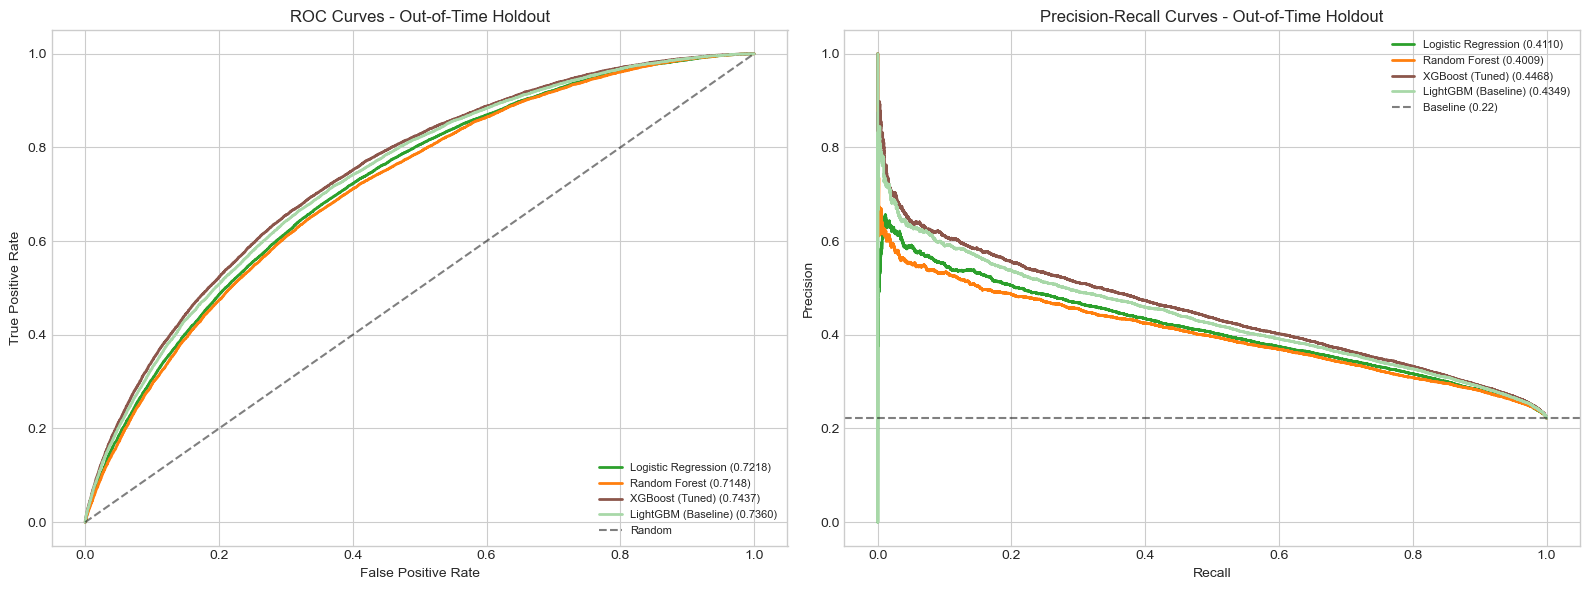

In [25]:
# Plot ROC and Precision-Recall curves for the finalist models on the holdout set
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_color_map = {
    "Logistic Regression": COLORS["lr"],
    "Random Forest": COLORS["rf"],
    "XGBoost (Baseline)": "#f5c6a0",
    "XGBoost (Tuned)": COLORS["xgb"],
    "LightGBM (Baseline)": "#a8d8a8",
    "LightGBM (Tuned)": COLORS["lgbm"],
}

# Left panel: ROC curves
for name, res in holdout_results.items():
    fpr, tpr, _ = roc_curve(y_holdout, res["y_prob"])
    axes[0].plot(
        fpr,
        tpr,
        label=f'{name} ({res["ROC-AUC"]:.4f})',
        color=plot_color_map.get(name, None),
        linewidth=2,
    )

axes[0].plot([0, 1], [0, 1], "k--", alpha=0.5, label="Random")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves - Out-of-Time Holdout")
axes[0].legend(loc="lower right", fontsize=8)

# Right panel: Precision-Recall curves
for name, res in holdout_results.items():
    precision, recall, _ = precision_recall_curve(y_holdout, res["y_prob"])
    axes[1].plot(
        recall,
        precision,
        label=f'{name} ({res["PR-AUC"]:.4f})',
        color=plot_color_map.get(name, None),
        linewidth=2,
    )

baseline_pr = y_holdout.mean()
axes[1].axhline(
    y=baseline_pr,
    color="k",
    linestyle="--",
    alpha=0.5,
    label=f"Baseline ({baseline_pr:.2f})",
)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curves - Out-of-Time Holdout")
axes[1].legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "roc_pr_curves_holdout.png", dpi=150, bbox_inches="tight")
plt.show()

### 5.2 Detailed Evaluation of the Validation-Selected Best Model

The detailed metrics below are shown for the model selected on the validation shortlist.

This keeps the workflow clean:

- validation is used to choose the model
- holdout is used only for final unseen evaluation

In [26]:
y_prob_best_val = finalists[best_name]["y_prob_val"]
y_prob_best_holdout = holdout_results[best_name]["y_prob"]

print(f"Validation-selected best model: {best_name}")
print(f"Validation ROC-AUC: {finalists[best_name]['Val ROC-AUC']:.4f}")
print(f"Validation PR-AUC:  {finalists[best_name]['Val PR-AUC']:.4f}")
print(f"Validation KS:      {finalists[best_name]['Val KS']:.4f}")
print(f"Holdout ROC-AUC:    {holdout_results[best_name]['ROC-AUC']:.4f}")
print(f"Holdout PR-AUC:     {holdout_results[best_name]['PR-AUC']:.4f}")
print(f"Holdout KS:         {holdout_results[best_name]['KS']:.4f}")

Validation-selected best model: XGBoost (Tuned)
Validation ROC-AUC: 0.7393
Validation PR-AUC:  0.4176
Validation KS:      0.3481
Holdout ROC-AUC:    0.7437
Holdout PR-AUC:     0.4468
Holdout KS:         0.3569


#### 5.2.1 Business-Aligned Threshold Selection

The probability threshold is selected on the **validation set**, not on the holdout set.

Here, the threshold that maximises **validation F1 score** for the validation-selected best model is used as a simple diagnostic threshold and then applied once to the holdout set.

In a production lending setting, the final threshold would usually be chosen using business objectives such as approval rate, expected loss, or risk appetite rather than F1 alone.

In [27]:
# We choose the classification threshold using the VALIDATION set only.
# This keeps the holdout set untouched until the final evaluation step.

# Create a grid of candidate thresholds from 0.01 to 0.99
threshold_grid = np.arange(0.01, 1.00, 0.01)

# Store validation metrics at each threshold
threshold_results = []

for threshold in threshold_grid:
    # Convert probabilities into class predictions using the candidate threshold
    y_pred_val = (y_prob_best_val >= threshold).astype(int)

    # Compute metrics on the validation set
    precision = precision_score(y_val, y_pred_val, zero_division=0)
    recall = recall_score(y_val, y_pred_val, zero_division=0)
    f1 = f1_score(y_val, y_pred_val, zero_division=0)
    accuracy = accuracy_score(y_val, y_pred_val)

    threshold_results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "accuracy": accuracy,
    })

# Convert results to DataFrame for easier inspection
threshold_df = pd.DataFrame(threshold_results)

# Pick the threshold that gives the highest validation F1 score
best_threshold_row = threshold_df.sort_values(
    ["f1", "precision", "recall"],
    ascending=[False, False, False]
).iloc[0]

best_threshold = float(best_threshold_row["threshold"])

print("=" * 60)
print(f"Validation-selected best model: {best_name}")
print(f"Chosen threshold (max validation F1): {best_threshold:.2f}")
print("=" * 60)

print("\nValidation metrics at chosen threshold:")
print(f"  Precision : {best_threshold_row['precision']:.4f}")
print(f"  Recall    : {best_threshold_row['recall']:.4f}")
print(f"  F1 score  : {best_threshold_row['f1']:.4f}")
print(f"  Accuracy  : {best_threshold_row['accuracy']:.4f}")

# Show the top threshold candidates on validation
print("\nTop 10 threshold candidates on validation:")
display(
    threshold_df.sort_values(
        ["f1", "precision", "recall"],
        ascending=[False, False, False]
    ).head(10).round(4)
)

# Apply the chosen threshold ONCE to the holdout set
y_pred_best_holdout = (y_prob_best_holdout >= best_threshold).astype(int)

# Compute holdout classification metrics at the chosen threshold
holdout_precision = precision_score(y_holdout, y_pred_best_holdout, zero_division=0)
holdout_recall = recall_score(y_holdout, y_pred_best_holdout, zero_division=0)
holdout_f1 = f1_score(y_holdout, y_pred_best_holdout, zero_division=0)
holdout_accuracy = accuracy_score(y_holdout, y_pred_best_holdout)

print("\nHoldout metrics at validation-selected threshold:")
print(f"  Precision : {holdout_precision:.4f}")
print(f"  Recall    : {holdout_recall:.4f}")
print(f"  F1 score  : {holdout_f1:.4f}")
print(f"  Accuracy  : {holdout_accuracy:.4f}")

Validation-selected best model: XGBoost (Tuned)
Chosen threshold (max validation F1): 0.54

Validation metrics at chosen threshold:
  Precision : 0.3617
  Recall    : 0.6110
  F1 score  : 0.4544
  Accuracy  : 0.7076

Top 10 threshold candidates on validation:


,threshold,precision,recall,f1,accuracy
53,0.54,0.3617,0.6110,0.4544,0.7076
54,0.55,0.3680,0.5930,0.4542,0.7159
52,0.53,0.3551,0.6286,0.4538,0.6984
51,0.52,0.3491,0.6460,0.4533,0.6893
55,0.56,0.3739,0.5736,0.4527,0.7235
50,0.51,0.3431,0.6624,0.4520,0.6799
56,0.57,0.3809,0.5555,0.4519,0.7314
49,0.50,0.3378,0.6794,0.4513,0.6707
57,0.58,0.3872,0.5367,0.4498,0.7383
48,0.49,0.3323,0.6947,0.4496,0.6609



Holdout metrics at validation-selected threshold:
  Precision : 0.3684
  Recall    : 0.6973
  F1 score  : 0.4821
  Accuracy  : 0.6674


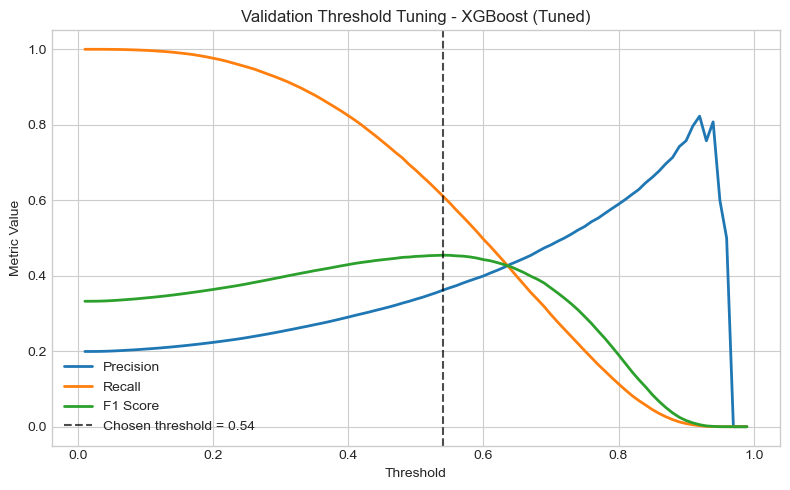

In [28]:
# Plot validation precision, recall, and F1 across thresholds
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision", linewidth=2)
ax.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall", linewidth=2)
ax.plot(threshold_df["threshold"], threshold_df["f1"], label="F1 Score", linewidth=2)

ax.axvline(best_threshold, linestyle="--", color="black", alpha=0.7, label=f"Chosen threshold = {best_threshold:.2f}")

ax.set_xlabel("Threshold")
ax.set_ylabel("Metric Value")
ax.set_title(f"Validation Threshold Tuning - {best_name}")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "threshold_tuning_validation.png", dpi=150, bbox_inches="tight")
plt.show()

#### 5.2.2 Confusion Matrix and Classification Report on Holdout
Using the threshold selected on the **validation set**, the holdout probabilities are converted into class predictions and evaluated with a classification report and confusion matrix.

This gives a more operational view of performance than ROC-AUC alone, because it shows the trade-off between:
- **false positives**: borrowers predicted to default who would actually repay
- **false negatives**: borrowers predicted to repay who would actually default

In a lending setting, the preferred balance depends on business priorities such as credit losses, approval rate, and risk appetite.

Holdout Classification Report - XGBoost (Tuned)
              precision    recall  f1-score   support

 Non-Default     0.8841    0.6589    0.7551     53948
     Default     0.3684    0.6973    0.4821     15391

    accuracy                         0.6674     69339
   macro avg     0.6263    0.6781    0.6186     69339
weighted avg     0.7696    0.6674    0.6945     69339

Confusion Matrix Counts:
  True Negatives  (TN): 35548
  False Positives (FP): 18400
  False Negatives (FN): 4659
  True Positives  (TP): 10732


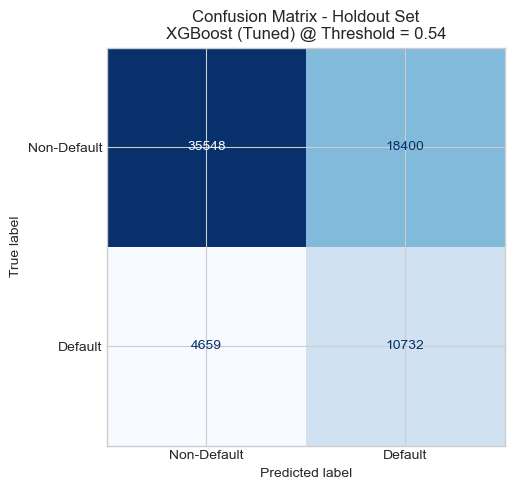

In [29]:
# ---------------------------------------------------------
# 5.2.2 Holdout Classification Report and Confusion Matrix
# ---------------------------------------------------------

# Print a full classification report for the holdout set
print("=" * 60)
print(f"Holdout Classification Report - {best_name}")
print("=" * 60)
print(
    classification_report(
        y_holdout,
        y_pred_best_holdout,
        target_names=["Non-Default", "Default"],
        digits=4,
        zero_division=0,
    )
)

# Compute confusion matrix
cm = confusion_matrix(y_holdout, y_pred_best_holdout)

tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix Counts:")
print(f"  True Negatives  (TN): {tn}")
print(f"  False Positives (FP): {fp}")
print(f"  False Negatives (FN): {fn}")
print(f"  True Positives  (TP): {tp}")

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Default", "Default"]
)
disp.plot(ax=ax, cmap="Blues", colorbar=False)

ax.set_title(f"Confusion Matrix - Holdout Set\n{best_name} @ Threshold = {best_threshold:.2f}")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "confusion_matrix_holdout.png", dpi=150, bbox_inches="tight")
plt.show()

> **Business interpretation:**
>
> - **True Positives (TP):** correctly identified defaulters. These are the risky borrowers the model successfully flags.
> - **True Negatives (TN):** correctly identified non-defaulters. These are borrowers the model correctly recognises as lower risk.
> - **False Positives (FP):** borrowers predicted to default who would actually repay. In practice, these can reduce approval rates and potentially reject profitable business.
> - **False Negatives (FN):** borrowers predicted to repay who would actually default. In practice, these can lead to avoidable credit losses.
>
> This trade-off is why the threshold should not be treated as purely statistical. In a real lending setting, the final threshold would normally be chosen based on expected loss, approval strategy, and risk appetite.

### 5.3 Population Stability Index (PSI) - Drift Assessment

The Population Stability Index (PSI) checks whether the distribution of the model's predicted scores has shifted between the development period and the out-of-time holdout period. A stable score distribution increases confidence that the model remains usable on later cohorts. A large shift indicates population of borrowers changed over time (eg. changing borrower characteristics, evolving risk patterns) which may need for recalibration and monitoring.

**PSI interpretation (industry convention):**

| PSI Value | Interpretation |
| :--- | :--- |
| PSI < 0.10 | No significant shift - model is relatively stable |
| 0.10 ≤ PSI < 0.25 | Moderate shift - monitor closely |
| PSI ≥ 0.25 | Significant shift - consider recalibration or retraining |

PSI is computed by:
1. Binning the training set scores into deciles
2. Computing the proportion of observations in each bin for both training and holdout
3. Summing the weighted log-ratio across bins:

$$\text{PSI} = \sum_{i=1}^{n} \left( P_{\text{train},i} - P_{\text{holdout},i} \right) \times \ln\left( \frac{P_{\text{train},i}}{P_{\text{holdout},i}} \right)$$

In [30]:
def compute_psi(train_scores, holdout_scores, n_bins=10, eps=1e-6):
    """
    Compute the Population Stability Index between training and holdout score distributions.
    """
    quantiles = np.linspace(0, 100, n_bins + 1)
    bin_edges = np.percentile(train_scores, quantiles)
    bin_edges[0] = 0.0
    bin_edges[-1] = 1.0

    train_counts = np.histogram(train_scores, bins=bin_edges)[0]
    holdout_counts = np.histogram(holdout_scores, bins=bin_edges)[0]

    train_pct = train_counts / len(train_scores)
    holdout_pct = holdout_counts / len(holdout_scores)

    train_pct = np.clip(train_pct, eps, None)
    holdout_pct = np.clip(holdout_pct, eps, None)

    psi_bins = (train_pct - holdout_pct) * np.log(train_pct / holdout_pct)
    psi_value = psi_bins.sum()

    psi_df = pd.DataFrame({
        "Bin": [f"[{bin_edges[i]:.3f}, {bin_edges[i+1]:.3f})" for i in range(n_bins)],
        "Train %": (train_pct * 100).round(2),
        "Holdout %": (holdout_pct * 100).round(2),
        "Difference %": ((train_pct - holdout_pct) * 100).round(2),
        "PSI (bin)": psi_bins.round(5),
    })

    return psi_value, psi_df, bin_edges


# Use the correct training feature matrix for the selected model
if best_name == "Logistic Regression":
    y_prob_train_best = best_model.predict_proba(X_train_lr)[:, 1]
else:
    y_prob_train_best = best_model.predict_proba(X_train)[:, 1]

psi_value, psi_df, bin_edges = compute_psi(y_prob_train_best, y_prob_best_holdout)

print("=" * 55)
print(f"PSI (Train vs Out-of-Time Holdout): {psi_value:.4f}")
if psi_value < 0.10:
    status = "STABLE - no significant population shift detected"
elif psi_value < 0.25:
    status = "MODERATE SHIFT - monitor score distribution closely"
else:
    status = "SIGNIFICANT SHIFT - consider recalibration or retraining"
print(f"Status: {status}")
print("=" * 55)
print("\nPer-bin breakdown:")
psi_df

PSI (Train vs Out-of-Time Holdout): 0.0365
Status: STABLE - no significant population shift detected

Per-bin breakdown:


,Bin,Train %,Holdout %,Difference %,PSI (bin)
0,"[0.000, 0.175)",10.0,9.09,0.91,0.00086
1,"[0.175, 0.254)",10.0,8.17,1.83,0.00372
2,"[0.254, 0.319)",10.0,7.90,2.10,0.00496
3,"[0.319, 0.380)",10.0,8.30,1.70,0.00319
4,"[0.380, 0.440)",10.0,8.67,1.33,0.00190
5,"[0.440, 0.500)",10.0,9.34,0.66,0.00045
6,"[0.500, 0.564)",10.0,10.41,-0.41,0.00017
7,"[0.564, 0.635)",10.0,11.54,-1.54,0.00221
8,"[0.635, 0.723)",10.0,12.75,-2.75,0.00670
9,"[0.723, 1.000)",10.0,13.83,-3.83,0.01240


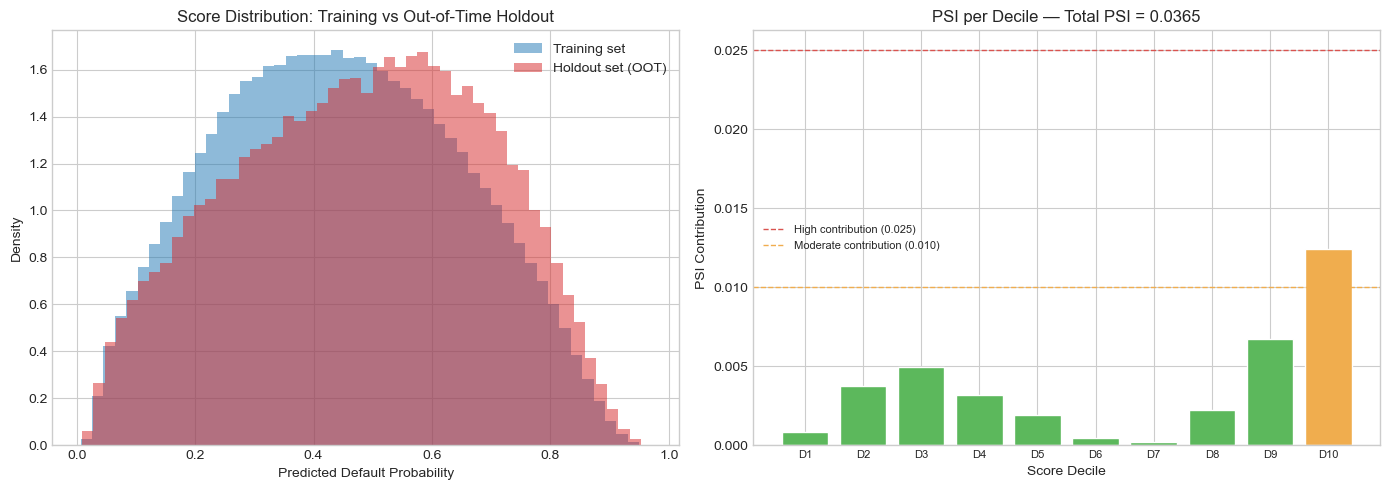

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left panel: Score distribution comparison (KDE)
axes[0].hist(y_prob_train_best,   bins=50, density=True, alpha=0.5,
             color=COLORS["non_default"], label="Training set")
axes[0].hist(y_prob_best_holdout, bins=50, density=True, alpha=0.5,
             color=COLORS["default"],     label="Holdout set (OOT)")
axes[0].set_xlabel("Predicted Default Probability")
axes[0].set_ylabel("Density")
axes[0].set_title("Score Distribution: Training vs Out-of-Time Holdout")
axes[0].legend()

# Right panel: PSI per bin
bar_colors_psi = [
    "#d9534f" if v >= 0.025 else "#f0ad4e" if v >= 0.010 else "#5cb85c"
    for v in psi_df["PSI (bin)"]
]
axes[1].bar(range(len(psi_df)), psi_df["PSI (bin)"], color=bar_colors_psi, edgecolor="white")
axes[1].axhline(y=0.025, color="#d9534f", linestyle="--", linewidth=1,
                label="High contribution (0.025)")
axes[1].axhline(y=0.010, color="#f0ad4e", linestyle="--", linewidth=1,
                label="Moderate contribution (0.010)")
axes[1].set_xticks(range(len(psi_df)))
axes[1].set_xticklabels([f"D{i+1}" for i in range(len(psi_df))], fontsize=8)
axes[1].set_xlabel("Score Decile")
axes[1].set_ylabel("PSI Contribution")
axes[1].set_title(f"PSI per Decile — Total PSI = {psi_value:.4f}")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "psi_drift_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

> **PSI interpretation:**
>
> A **PSI < 0.10** suggests that the model's score distribution is stable between the training period and the out-of-time holdout period. This means the borrower population did not shift materially over this time window.
>
> This supports the view that the model remains reasonably stable on later unseen data.
> In a production setting, PSI would typically be recomputed regularly against the original development distribution. A sustained increase above 0.10 would trigger closer monitoring, and a PSI above 0.25 would usually justify recalibration or retraining.

## 6. Interpretation and Model Comparison

### 6.1 Model Comparison Summary

In [32]:
summary = val_summary.copy()
summary["Holdout ROC-AUC"] = pd.Series({name: res["ROC-AUC"] for name, res in holdout_results.items()})
summary["Holdout PR-AUC"] = pd.Series({name: res["PR-AUC"] for name, res in holdout_results.items()})
summary["Holdout KS"] = pd.Series({name: res["KS"] for name, res in holdout_results.items()})
summary["Holdout Gini"] = pd.Series({name: res["Gini"] for name, res in holdout_results.items()})
summary["Holdout Brier"] = pd.Series({name: res["Brier"] for name, res in holdout_results.items()})

summary["Val-Holdout ROC Gap"] = summary["Val ROC-AUC"] - summary["Holdout ROC-AUC"]
summary["Val-Holdout KS Gap"] = summary["Val KS"] - summary["Holdout KS"]

summary = summary.sort_values(["Val ROC-AUC", "Val KS", "Val PR-AUC"], ascending=[False, False, False])
summary

,Val ROC-AUC,Val PR-AUC,Val KS,Val Gini,Val Brier,Holdout ROC-AUC,Holdout PR-AUC,Holdout KS,Holdout Gini,Holdout Brier,Val-Holdout ROC Gap,Val-Holdout KS Gap
XGBoost (Tuned),0.739320,0.417560,0.348141,0.478640,0.205865,0.743664,0.446817,0.356874,0.487328,0.222028,-0.004344,-0.008734
LightGBM (Baseline),0.735481,0.412151,0.342731,0.470962,0.209375,0.736047,0.434905,0.346169,0.472095,0.227756,-0.000567,-0.003438
Logistic Regression,0.727496,0.398193,0.331860,0.454993,0.211504,0.721788,0.411035,0.324944,0.443576,0.231758,0.005708,0.006916
Random Forest,0.720085,0.389129,0.316499,0.440170,0.214808,0.714843,0.400903,0.314152,0.429686,0.234642,0.005242,0.002348


> **Model selection rationale:**
>
> The final model is selected using **validation ROC-AUC** as the primary ranking metric, with **validation KS** and **validation PR-AUC** used as supporting diagnostics.
>
> This is appropriate because:
> - **ROC-AUC** measures ranking quality across thresholds
> - **KS** measures class separation and is widely used in credit-risk modelling
> - **PR-AUC** provides additional insight into minority-class performance
> - **Brier score** helps assess probability quality
>
> The holdout set is used only for final unseen evaluation. The validation-to-holdout gaps are reported as diagnostics for generalisation and temporal robustness.

### 6.2 Feature Importance of the Selected Model

This section shows which features the validation-selected final model relies on most heavily.

For tree-based models, the chart below uses the model's built-in feature importance values.  
For Logistic Regression, absolute coefficient magnitude is used instead.

This plot is useful for identifying the model's strongest predictive signals, but it should be interpreted carefully:

- feature importance does **not** show direction of effect
- feature importance does **not** imply causality
- correlated or duplicated variables can both appear highly important

For directional interpretation, the SHAP analysis below is more informative.

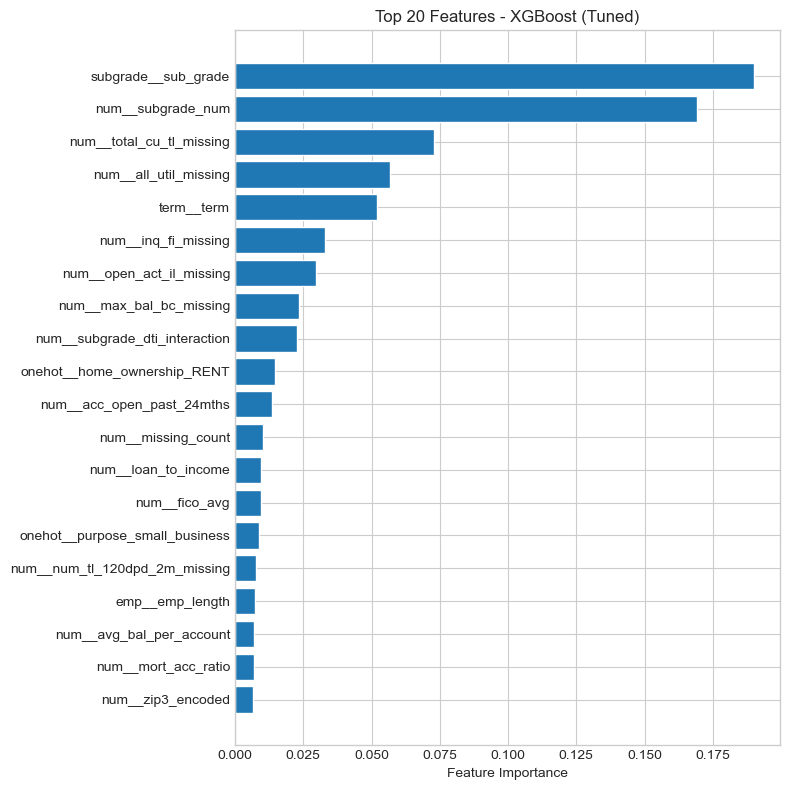


Top 5 features:
  subgrade__sub_grade                      0.1901
  num__subgrade_num                        0.1693
  num__total_cu_tl_missing                 0.0730
  num__all_util_missing                    0.0568
  term__term                               0.0520


In [33]:
# Use the correct feature names for the selected model
if best_name == "Logistic Regression":
    current_feature_names = lr_final_features
else:
    current_feature_names = feature_names
    
# Extracts an importance value from the model
if hasattr(best_model, "feature_importances_"):
    importance_vals = best_model.feature_importances_
    imp_label = "Feature Importance"
elif hasattr(best_model, "coef_"):
    importance_vals = np.abs(best_model.coef_[0])
    imp_label = "Absolute Coefficient"
else:
    importance_vals = np.zeros(len(current_feature_names))
    imp_label = "Feature Importance (unavailable)"

top_n = min(20, len(current_feature_names))

imp_df = pd.DataFrame({
    "feature": current_feature_names,
    "importance": importance_vals,
}).sort_values("importance", ascending=False)

top_features = imp_df.head(top_n)

fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(
    range(top_n),
    top_features["importance"].values[::-1],
    color=COLORS["non_default"],
    edgecolor="white",
)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features["feature"].values[::-1])
ax.set_xlabel(imp_label)
ax.set_title(f"Top {top_n} Features - {best_name}")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "feature_importance_best.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nTop 5 features:")
for _, row in top_features.head(5).iterrows():
    print(f"  {row['feature']:40s} {row['importance']:.4f}")

> **Key feature importance findings:**
>
> - The tuned XGBoost model is driven most strongly by **Lending Club’s sub-grade information**, with both `subgrade__sub_grade` and `num__subgrade_num` ranking at the top. This suggests that the lender’s internal underwriting grade already captures a large share of default-risk signal.
> - Several **missing-value indicators** such as `total_cu_tl_missing`, `all_util_missing`, and `open_act_il_missing` also appear among the most important features. This suggests that missingness itself carries information about borrower profile or credit-file structure.
> - **Loan term** is another important predictor, indicating that product structure contributes meaningfully to default-risk separation.
> - A small number of **engineered features** such as `subgrade_dti_interaction`, `loan_to_income`, and `avg_bal_per_account` remain relevant, suggesting that borrower-level financial burden and interaction effects add useful signal beyond the raw variables.
> - These importances should be interpreted cautiously: tree-based feature importance shows which variables the model uses most for prediction, but it does not show direction of effect or imply causality. Directional interpretation is better handled with SHAP.

### 6.3 SHAP Explainability

SHAP (SHapley Additive exPlanations) provides a rigorous, game-theory-based decomposition of each prediction into per-feature contributions. For a given observation, each SHAP value represents how much that feature pushed the predicted default probability above or below the population average. SHAP (SHapley Additive exPlanations) is used as the **primary explainability method** for the selected tree-based model.

**Why is SHAP used:**
- **Additive and consistent**: Feature contributions sum exactly to the difference between the prediction and the baseline, ensuring a complete and interpretable breakdown
- **Model-compatible and efficient**:Tree-based models use `TreeExplainer`, which computes SHAP values efficiently without approximation

2 views are provided:
1. **Global summary plot**: Shows overall feature importance across the dataset
- Features are ranked by impact  
- Colour indicates feature value (high vs low)

2. **Waterfall plot**: Shows how individual features contribute to a single prediction  
- Starts from the baseline  
- Adds or subtracts feature contributions step by step  
- Useful for explaining decisions to credit officers or regulators

In [34]:
tree_model_names = {
    "Random Forest",
    "XGBoost (Baseline)",
    "XGBoost (Tuned)",
    "LightGBM (Baseline)",
    "LightGBM (Tuned)",
    "XGBoost",
}

if best_name not in tree_model_names:
    print("SHAP TreeExplainer skipped because the selected model is not tree-based.")
else:
    print("Computing SHAP values on the full holdout set...")

    # Use the entire holdout set
    X_shap_sample = X_holdout
    y_shap_sample = y_holdout

    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_shap_sample)

    # For binary classifiers, shap_values may be a list [class0, class1].
    # We want the values for the positive class (default = 1).
    if isinstance(shap_values, list):
        shap_vals_pos = shap_values[1]
        expected_value = explainer.expected_value[1]
    else:
        shap_vals_pos = shap_values
        expected_value = explainer.expected_value

    print(f"SHAP values computed. Shape: {shap_vals_pos.shape}")
    print(f"Expected value (baseline output): {expected_value:.4f}")

Computing SHAP values on the full holdout set...
SHAP values computed. Shape: (69339, 118)
Expected value (baseline output): 0.0048


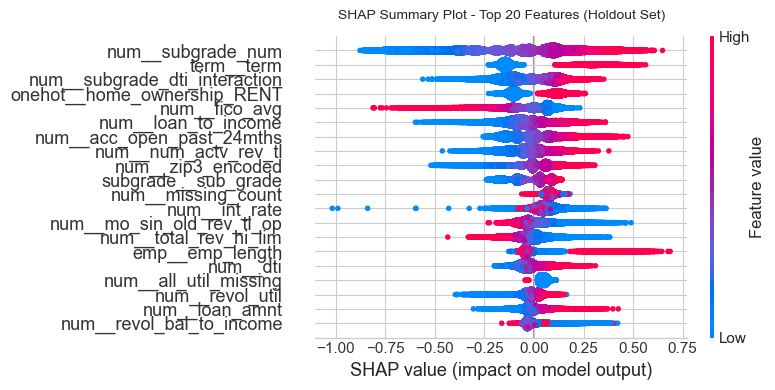

In [35]:
# Global SHAP summary plot
# Each row is a feature and each dot is one holdout observation.
# Colour shows whether the feature value is relatively high or low.
# The SHAP value shows whether that feature pushes the model output upward or downward for that observation.

shap.summary_plot(
    shap_vals_pos,
    X_shap_sample,
    feature_names=feature_names,
    max_display=20,
    show=False,
    plot_size=(8, 4),
)

plt.title("SHAP Summary Plot - Top 20 Features (Holdout Set)", fontsize=10, pad=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

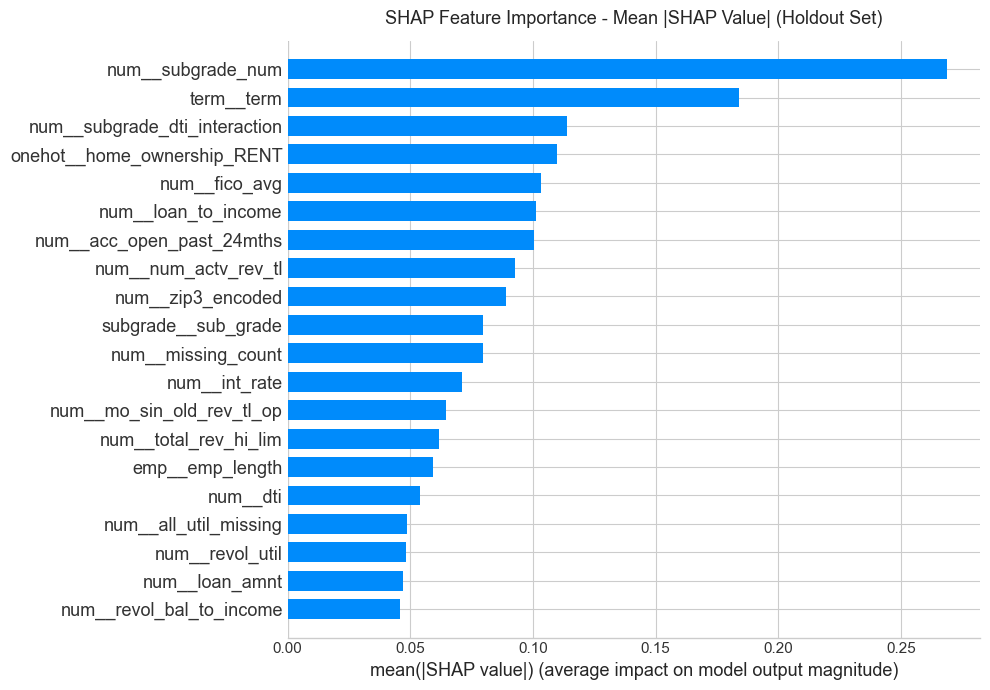

In [36]:
# SHAP bar plot (mean absolute SHAP values)
# This is a global importance view showing the average absolute contribution
# of each feature to the model output across the holdout set.
# It is not the same as permutation importance:
# - SHAP importance is based on the model's local attributions
# - permutation importance is based on performance drop after shuffling a feature

shap.summary_plot(
    shap_vals_pos,
    X_shap_sample,
    feature_names=feature_names,
    max_display=20,
    plot_type="bar",
    show=False,
    plot_size=(10, 7),
)

plt.title("SHAP Feature Importance - Mean |SHAP Value| (Holdout Set)", fontsize=13, pad=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "shap_importance_bar.png", dpi=150, bbox_inches="tight")
plt.show()

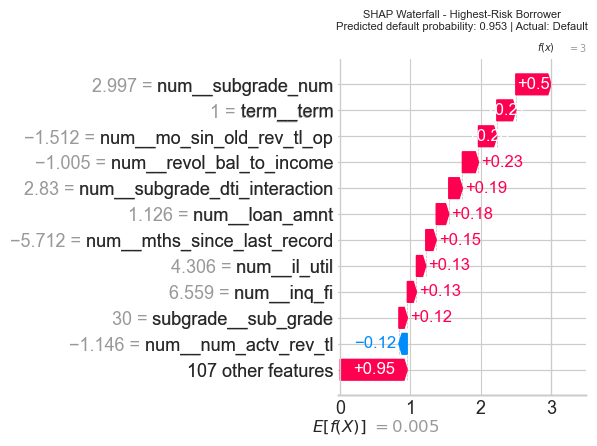

Borrower index in SHAP set: 32446
Predicted default probability: 0.9526
Actual label: Default (1)


In [37]:
# SHAP waterfall plot for a single high-risk borrower
# Goal:
# Show the largest feature contributions behind the selected model output
# for one borrower. Here, we choose the borrower with the highest predicted
# default probability within the SHAP evaluation set.

# Get predicted default probabilities for the SHAP evaluation set
y_prob_shap_sample = best_model.predict_proba(X_shap_sample)[:, 1]

# Identify the highest-risk borrower in the SHAP evaluation set
high_risk_idx = np.argmax(y_prob_shap_sample)

# Build a SHAP Explanation object for the selected borrower
# We use the SHAP values for the positive class and the corresponding
# baseline output prepared earlier.
shap_explanation = shap.Explanation(
    values=shap_vals_pos[high_risk_idx],
    base_values=expected_value,
    data=X_shap_sample[high_risk_idx],
    feature_names=feature_names,
)

# Set smaller font sizes before plotting
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.labelsize"] = 7
plt.rcParams["ytick.labelsize"] = 7

# Draw the SHAP waterfall plot
shap.waterfall_plot(shap_explanation, max_display=12, show=False)

# Resize after SHAP creates the figure
fig = plt.gcf()
fig.set_size_inches(6, 4.5)

# Tighten axis font sizes
ax = plt.gca()
ax.tick_params(axis="both", labelsize=7)

for txt in ax.texts:
    txt.set_fontsize(7)

for label in ax.get_xticklabels():
    label.set_fontsize(7)

for label in ax.get_yticklabels():
    label.set_fontsize(7)

# Add title
plt.title(
    f"SHAP Waterfall - Highest-Risk Borrower\n"
    f"Predicted default probability: {y_prob_shap_sample[high_risk_idx]:.3f} | "
    f"Actual: {'Default' if y_shap_sample[high_risk_idx] == 1 else 'Non-Default'}",
    fontsize=8,
    pad=8,
)

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "shap_waterfall_high_risk.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

print(f"Borrower index in SHAP set: {high_risk_idx}")
print(f"Predicted default probability: {y_prob_shap_sample[high_risk_idx]:.4f}")
print(f"Actual label: {'Default (1)' if y_shap_sample[high_risk_idx] == 1 else 'Non-Default (0)'}")

> SHAP interpretation summary

The SHAP outputs suggest that the selected XGBoost model is relying on a coherent set of credit-risk signals.

Globally, the model is driven most strongly by Lending Club's internal subgrade information, loan term, borrower burden measures, housing status, recent credit activity, and credit quality. The direction of effect is broadly intuitive: worse subgrade, longer term, and higher affordability burden tend to push model risk upward, while stronger credit quality tends to push it downward.
b
The local waterfall plot for the highest-risk borrower shows that the model's extreme prediction is not driven by one single variable, but by the cumulative effect of several adverse signals acting together. Although this borrower was ultimately a non-default, the explanation still appears economically plausible, which supports the reasonableness of the model's decision process even in a false-positive case.

The SHAP analysis is broadly consistent with the earlier feature-importance chart, but it gives a more nuanced view of model behaviour.

Both approaches identify Lending Club's internal subgrade information as the dominant signal, with loan term and engineered burden features also playing important roles. However, SHAP provides two additional benefits. First, it shows the direction of effect: worse subgrade, longer term, and higher affordability burden tend to push model risk upward, while stronger credit quality tends to push it downward. Second, SHAP gives a more balanced picture of global importance, suggesting that some missing-value indicators that appeared very prominent in the built-in tree importance ranking may have less average impact on model output than the earlier chart implied.

Taken together, the earlier feature-importance plot is useful as a quick global screening tool, while SHAP provides the more reliable interpretation of how the selected model is actually behaving.

> **SHAP vs Feature Importance Interpretation**
>
> The SHAP analysis is broadly consistent with the earlier feature-importance chart, but it provides a more nuanced view of model behaviour.
>
> **Key alignment**
> - Lending Club’s internal subgrade is the dominant signal
> - Loan term is an important factor
> - Engineered burden features are significant contributors
>
> **What SHAP adds**
>
> **Direction of effect**
> - Worse subgrade tends to push model risk upward
> - Longer loan term tends to push model risk upward
> - Borrowers whose loan or debt burden is high relative to their income tend to be scored as riskier
> - Stronger credit quality tends to push model risk downward
>
> **More balanced global importance**
> - Some missing-value indicators ranked highly in the built-in tree-based importance chart
> - But they appear to have lower average impact when evaluated using SHAP

### 6.3 LIME Explainability

LIME(Local Interpretable Model-agnostic Explanations) is included as a **secondary local explanation tool**.

Unlike SHAP, LIME does not compute an exact additive decomposition from the selected model itself.  
Instead, LIME creates many slightly modified versions of one borrower, checks how the selected model scores those nearby cases, and then fits a simple local model to approximate the prediction around that borrower.

In this notebook, LIME is used mainly to answer one question:

> Does a second local explanation method tell a broadly similar story for the same high-risk borrower?

This makes LIME useful as a **sanity check** on borrower-level explanation rather than the primary explainability method.

Important interpretation notes:

- LIME is only **locally valid**
- LIME explanations can vary depending on the perturbation sample
- exact agreement with SHAP is not required
- agreement on the strongest few drivers is reassuring
- disagreement on minor drivers is normal

For this reason, SHAP remains the main explainability method in this project, while LIME is used as a supplementary cross-check.

In [38]:
# Build the LIME explainer using the correct training matrix for the selected model.
# LIME is used here as a supplementary local explanation tool.

if best_name == "Logistic Regression":
    X_train_lime = X_train_lr
    lime_feature_names = lr_final_features
    X_instance_lime = X_holdout_lr[high_risk_idx]
else:
    X_train_lime = X_train
    lime_feature_names = feature_names
    X_instance_lime = X_shap_sample[high_risk_idx]

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_lime,
    feature_names=lime_feature_names,
    class_names=["Non-Default", "Default"],
    mode="classification",
    discretize_continuous=True,
    random_state=SEED,
)

print("LIME explainer initialised.")
print(f"Training background: {X_train_lime.shape[0]:,} observations, {X_train_lime.shape[1]} features")

LIME explainer initialised.
Training background: 960,780 observations, 118 features


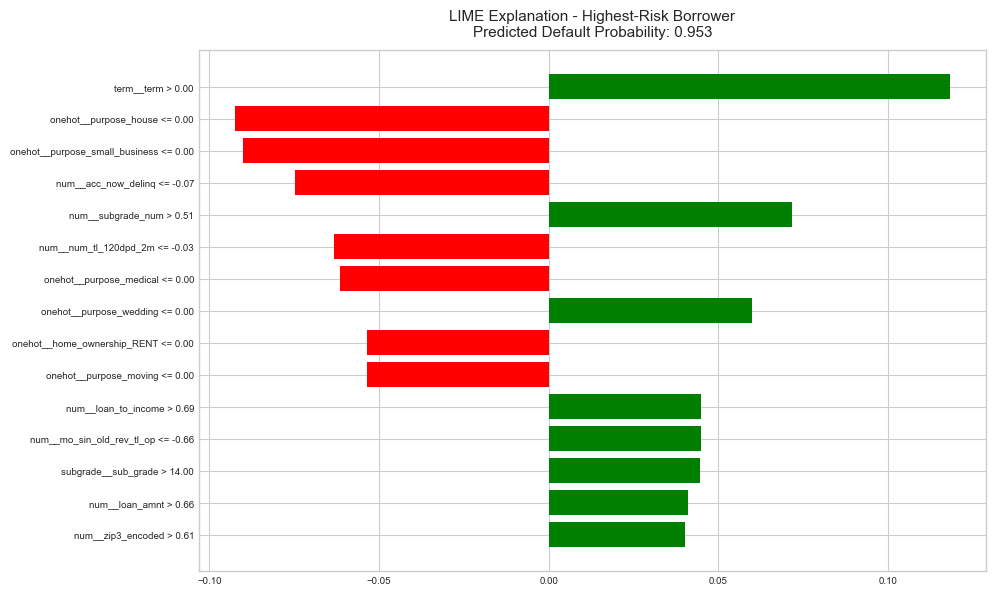


LIME top feature contributions (positive = increases local predicted risk):
  term__term > 0.00                                       +0.1184
  onehot__purpose_house <= 0.00                           -0.0926
  onehot__purpose_small_business <= 0.00                  -0.0901
  num__acc_now_delinq <= -0.07                            -0.0748
  num__subgrade_num > 0.51                                +0.0718
  num__num_tl_120dpd_2m <= -0.03                          -0.0633
  onehot__purpose_medical <= 0.00                         -0.0615
  onehot__purpose_wedding <= 0.00                         +0.0600
  onehot__home_ownership_RENT <= 0.00                     -0.0536
  onehot__purpose_moving <= 0.00                          -0.0535
  num__loan_to_income > 0.69                              +0.0449
  num__mo_sin_old_rev_tl_op <= -0.66                      +0.0448
  subgrade__sub_grade > 14.00                             +0.0445
  num__loan_amnt > 0.66                                   +0.0410

In [39]:
# LIME explanation for the same high-risk borrower used in SHAP where possible
# This allows a rough directional comparison between SHAP and LIME.

lime_exp = lime_explainer.explain_instance(
    data_row=X_instance_lime,
    predict_fn=best_model.predict_proba,
    num_features=15,
    num_samples=1000,
    labels=(1,),
)

# Plot the LIME explanation
fig = lime_exp.as_pyplot_figure(label=1)
fig.set_size_inches(10, 6)
plt.title(
    f"LIME Explanation - Highest-Risk Borrower\n"
    f"Predicted Default Probability: {y_prob_shap_sample[high_risk_idx]:.3f}",
    fontsize=11,
    pad=10,
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "lime_explanation_high_risk.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nLIME top feature contributions (positive = increases local predicted risk):")
for feat, weight in lime_exp.as_list(label=1):
    direction = "+" if weight > 0 else ""
    print(f"  {feat:<55s} {direction}{weight:.4f}")

> **LIME Interpretation**

> The LIME explanation is broadly consistent with the SHAP waterfall plot. The strongest local risk drivers for this borrower are loan term, weak subgrade, and renter status, which matches the main borrower-level story already seen in SHAP.  
> Some of the smaller LIME rules are less intuitive, especially those expressed as one-hot absence conditions or thresholds in transformed feature space. This is expected, because LIME is fitting a local surrogate model on the processed feature matrix rather than directly explaining raw borrower attributes.  
> Overall, the most important takeaway is not the exact value of every local LIME coefficient, but the fact that LIME and SHAP agree on the dominant drivers of the model’s high-risk prediction.

## 7. Save Artefacts and Business Conclusions

In [40]:
models_to_save = {name: res["model"] for name, res in finalists.items()}

with open(MODEL_DIR / "all_models.pkl", "wb") as f:
    pickle.dump(models_to_save, f)

with open(MODEL_DIR / "final_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

with open(MODEL_DIR / "results_summary.pkl", "wb") as f:
    pickle.dump({
        "all_validation_results": all_results,
        "all_validation_summary": all_val_summary,
        "final_validation_results": finalists,
        "final_validation_summary": val_summary,
        "holdout_results": holdout_results,
        "holdout_summary": holdout_summary,
        "model_comparison_summary": summary,
    }, f)

with open(MODEL_DIR / "best_model_metadata.pkl", "wb") as f:
    pickle.dump({
        "best_model_name": best_name,
        "best_threshold": float(best_threshold),
        "feature_names": feature_names,
        "lr_final_features": lr_final_features,
        "best_xgb_variant": best_xgb_name,
        "best_lgbm_variant": best_lgbm_name,
        "xgb_best_params": xgb_study.best_params,
        "lgbm_best_params": lgbm_study.best_params,
    }, f)

print(f"All model artefacts saved to: {MODEL_DIR}")
print(f"Validation-selected best model: {best_name}")
print("Saved files:")
print("  - all_models.pkl")
print("  - final_model.pkl")
print("  - results_summary.pkl")
print("  - best_model_metadata.pkl")

All model artefacts saved to: ../models
Validation-selected best model: XGBoost (Tuned)
Saved files:
  - all_models.pkl
  - final_model.pkl
  - results_summary.pkl
  - best_model_metadata.pkl


### 7.1 Summary and Business Conclusions

#### Key Takeaways

1. **All candidate models outperform random prediction**, confirming that the origination-time features contain meaningful default-risk signal.

2. **XGBoost and LightGBM emerged as the strongest benchmark models on validation**, with XGBoost slightly ahead on ROC-AUC and LightGBM very close overall. Because the gap was small, both models were tuned with Optuna before final selection.

3. **Validation-based model selection was used throughout**, while the out-of-time holdout set was reserved strictly for final unseen evaluation. This helps keep model selection and final performance assessment separate.

4. **ROC-AUC was the primary ranking metric**, with **KS** and **PR-AUC** used as supporting diagnostics to reflect credit-risk separation and minority-class ranking quality.

5. **The final selected model appears to rely on a coherent set of credit-risk signals**, with underwriting subgrade, loan term, and borrower burden measures emerging as the most important drivers. SHAP and LIME local explanations were broadly consistent on the dominant borrower-level risk factors.

6. **Threshold choice should reflect business objectives**, not just statistical optimisation. The validation-selected threshold shown here is a diagnostic starting point rather than a final production cutoff.

7. **PSI was used as a supplementary stability check**, helping assess whether the score distribution shifted materially between the development period and the later holdout period. PSI supports drift monitoring, but it is not a substitute for predictive performance evaluation.

#### Business Applications

- **Automated screening:** Flag higher-risk applications for enhanced review
- **Risk-based pricing:** Incorporate risk ranking into loan pricing decisions
- **Portfolio monitoring:** Extend the framework to monitor deterioration in booked loans over time

#### Limitations and Next Steps

- **Temporal stability:** The workflow was developed on loans from 2007 to June 2017, with final unseen evaluation on a Jul to Dec 2017 out-of-time holdout. Ongoing monitoring would still be needed.
- **Feature scope:** Geographic features were simplified upstream for tractability. More advanced geographic handling could be explored later.
- **Calibration:** Strong ranking performance does not guarantee calibrated probabilities. Calibration should be considered before using outputs directly as PD estimates.
- **Hyperparameter tuning:** Tuning was applied to both boosting models because their baseline validation performance was very close.
- **Cost-sensitive optimisation:** Future work could optimise directly against expected profit or expected loss instead of general classification metrics.
- **Interpretability scope:** SHAP and LIME were used to improve transparency, but local explanations should ideally be reviewed across a wider range of true positives, false positives, and borderline cases.

This project is designed to demonstrate an **end-to-end machine learning workflow** for credit-risk style default prediction: target definition, leakage handling, preprocessing, feature engineering, model benchmarking, hyperparameter tuning, out-of-time evaluation, stability checking, and explainability.

It should therefore be viewed as a well-structured baseline rather than a final production-ready system. There are several meaningful directions for improvement, including broader model tuning, stronger probability calibration, more extensive temporal validation, tighter handling of duplicated signals such as multiple subgrade representations, and more business-driven threshold setting based on expected loss, approval strategy, or risk appetite.

**Notebook 04 is complete.** The final selected model was chosen on validation performance and then evaluated once on an untouched out-of-time holdout set.